In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

stats_dir = Path('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe')

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/mesh2_spectrum_poles_QSO_z0.8-2.1_GCcomb_weight-default-FKP_0.h5


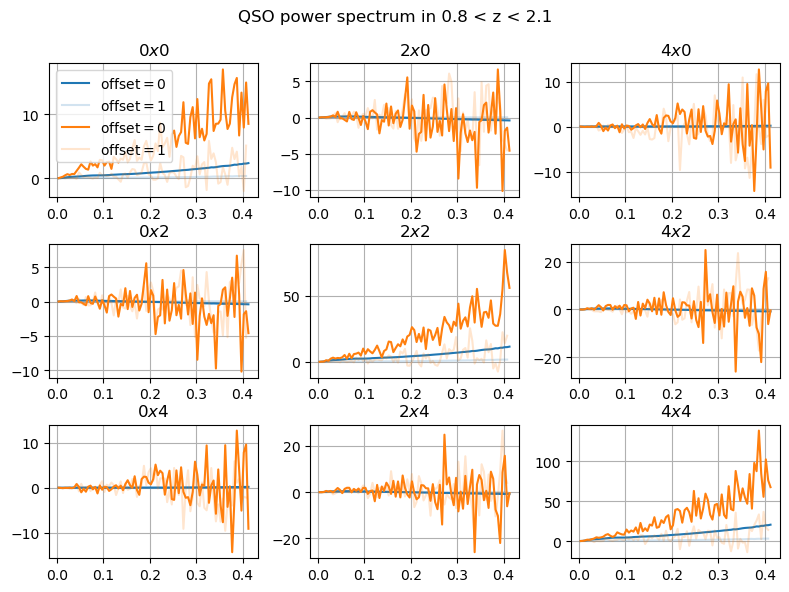

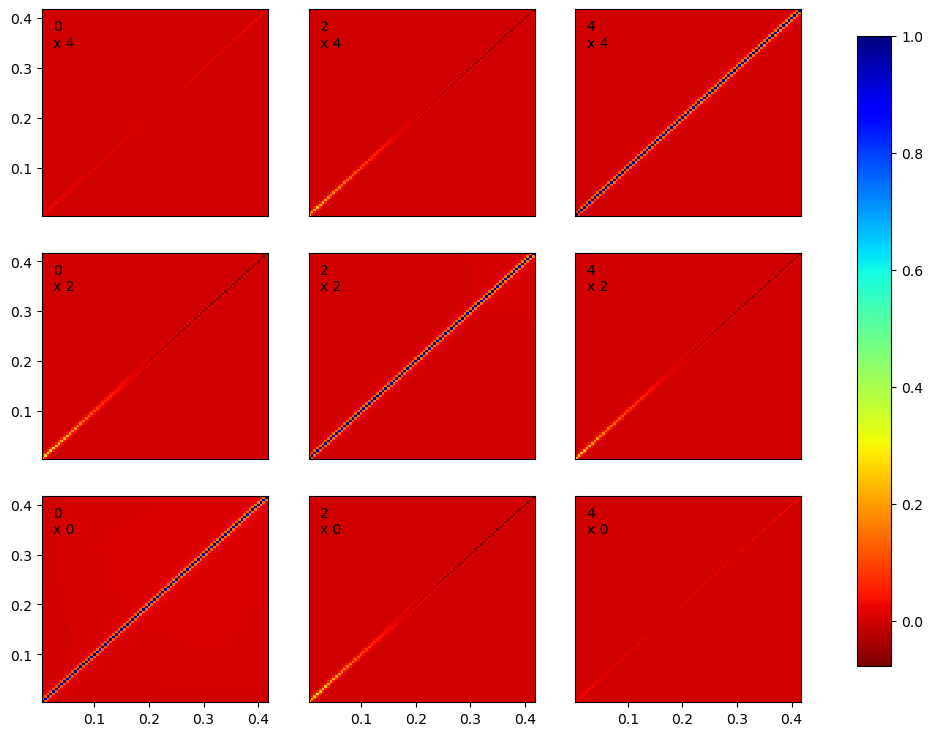

In [10]:
for tracer in ['LRG', 'ELG_LOP', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        kind = 'mesh2_spectrum'
        fn = tools.get_stats_fn(stats_dir=stats_dir, kind=f'covariance_{kind}', version='abacus-2ndgen-complete', tracer=tracer,
                                zrange=zrange, region='GCcomb', weight='default-FKP', imock=0)
        covariance_analytic = types.read(fn)
        covariance_analytic = covariance_analytic.at.observable.get(observables='spectrum2', tracers=(tools.get_simple_tracer(tracer),) * 2)
        fns = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, version='abacus-2ndgen-complete', tracer=tracer,
                                zrange=zrange, region='GCcomb', weight='default-FKP', imock='*')
        covariance_mocks = types.cov([types.read(fn) for fn in fns])
        observable = covariance_mocks.observable.select(k=slice(0, None, 5))
        covariance_analytic = covariance_analytic.at.observable.match(observable)
        covariance_mocks = covariance_mocks.at.observable.match(observable)
        kw = dict(ytransform=lambda x, y: x**4 * y, offset=np.arange(2))
        fig = covariance_analytic.plot_diag(**kw, show=False, color='C0')
        fig.suptitle(f'{tracer} power spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
        covariance_mocks.plot_diag(**kw, fig=fig, color='C1', show=True)
        covariance_analytic.plot(corrcoef=True, show=True);